In [3]:


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import re, string, unicodedata
from string import punctuation
from termcolor import colored
from collections import Counter

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import nltk
from nltk.corpus import stopwords
from textblob import Word
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag
from nltk.corpus import wordnet

from warnings import filterwarnings
filterwarnings('ignore')

from sklearn import set_config



[nltk_data] Downloading package stopwords to /home/ismail/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ismail/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/ismail/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:


data = pd.read_csv("./spam.csv", encoding = "ISO-8859-1", engine = "python")

print(colored("\nDATASETS WERE SUCCESFULLY LOADED...",  color = "green", attrs = ["bold", "dark"]))




DATASETS WERE SUCCESFULLY LOADED...


In [6]:
#rename dataset columns
data.rename(columns = {"v1": "target", "v2": "text"}, inplace = True)

#drop unnecessary columns
data.drop(["Unnamed: 2","Unnamed: 3", "Unnamed: 4"], axis = 1, inplace = True)

print(colored("\nOPERATIONS ON DATASETS WERE SUCCESFULLY COMPLETED...",  color = "green", attrs = ["bold", "dark"]))




OPERATIONS ON DATASETS WERE SUCCESFULLY COMPLETED...


In [7]:
data.info(memory_usage = True, verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [8]:
print(colored("There are {} duplicated values in the dataset".format(data.duplicated().sum()), color = "green", attrs = ["bold", "dark"]))


There are 403 duplicated values in the dataset


In [9]:
data.drop_duplicates(inplace = True)

print(colored("\nDUPLICATED VALUES WERE SUCCESFULLY DROPPED...", color = "green", attrs = ["bold", "dark"]))


DUPLICATED VALUES WERE SUCCESFULLY DROPPED...


In [11]:

grouped_target = data.groupby("target").count()
grouped_target["text"]



target
ham     4516
spam     653
Name: text, dtype: int64

In [12]:
data["ch_no"] = data["text"].apply(len)
data["wd_no"] = data.apply(lambda row: nltk.word_tokenize(row["text"]), axis=1).apply(len)
data["sn_no"] = data.apply(lambda row: nltk.sent_tokenize(row["text"]), axis=1).apply(len)

data.describe().T.style.background_gradient(cmap = "Purples_r")

,count,mean,std,min,25%,50%,75%,max
ch_no,5169.000000,78.977945,58.236293,2.000000,36.000000,60.000000,117.000000,910.000000
wd_no,5169.000000,18.455794,13.324758,1.000000,9.000000,15.000000,26.000000,220.000000
sn_no,5169.000000,1.965564,1.448541,1.000000,1.000000,1.000000,2.000000,38.000000


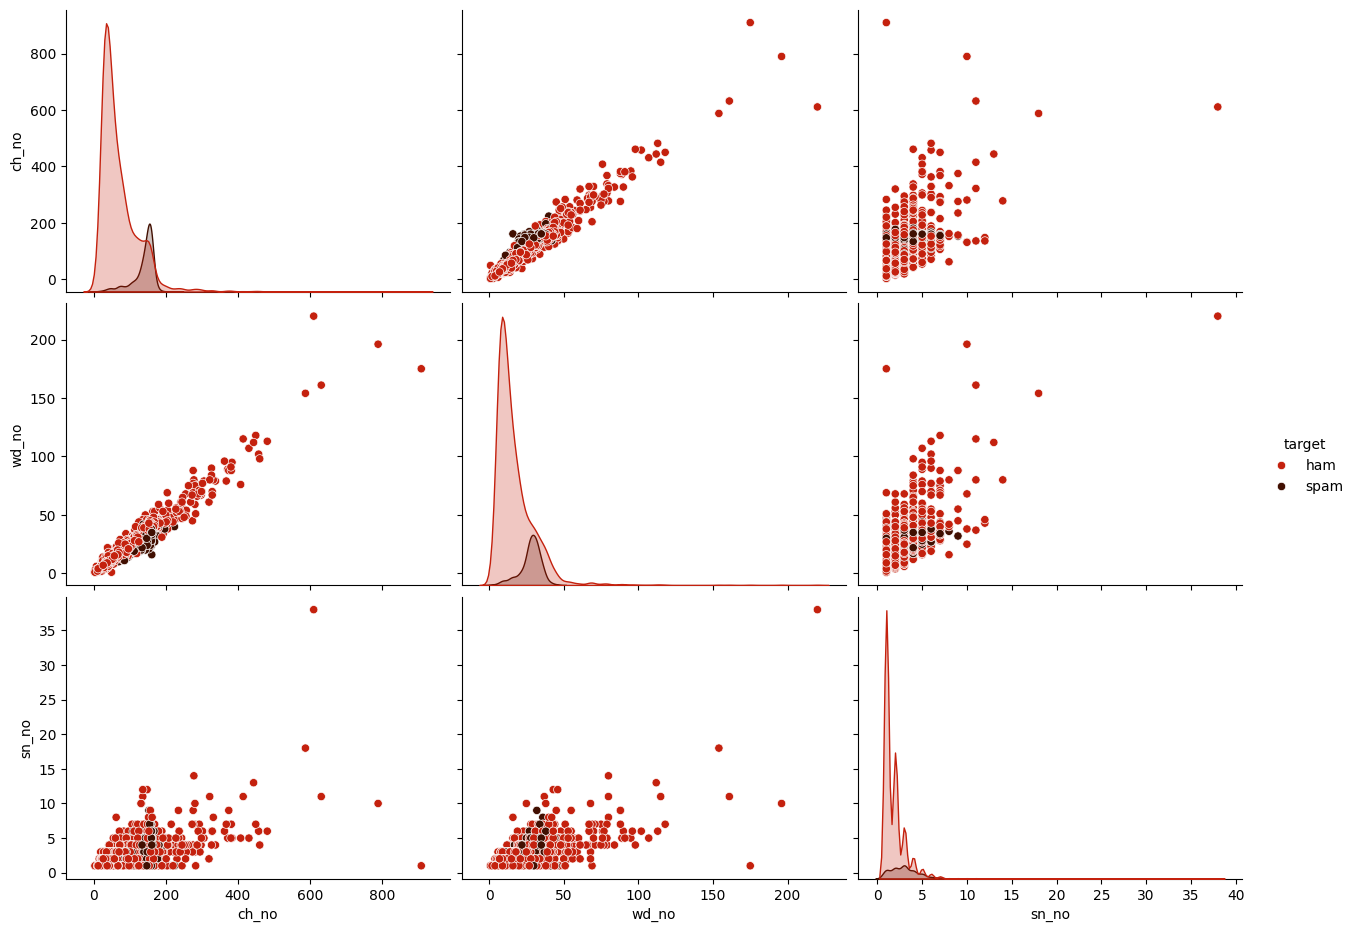

In [14]:
fig = sns.pairplot(data = data, hue = "target", palette = ["#C4210E", "#410F01"], height = 3.15, aspect = 1.35)
plt.show(fig);

In [15]:
data["text"] = data["text"].apply(lambda x: " ".join(x.lower() for x in x.split()))

print(colored("\nUPPERCASE LETTERS WERE SUCCESFULLY CONVERTED INTO LOWERCASE LETTERS...", color = "green", attrs = ["bold", "dark"]))



UPPERCASE LETTERS WERE SUCCESFULLY CONVERTED INTO LOWERCASE LETTERS...


In [16]:
data["text"] = data["text"].str.replace('[^\w\s]','')

print(colored("\nPUNCTUATION MARKS WERE SUCCESFULLY DELETED...", color = "green", attrs = ["bold", "dark"]))


PUNCTUATION MARKS WERE SUCCESFULLY DELETED...


In [17]:


data["text"] = data["text"].str.replace('\d','')

print(colored("\nNUMBERS WERE SUCCESFULLY DELETED...", color = "green", attrs = ["bold", "dark"]))




NUMBERS WERE SUCCESFULLY DELETED...


In [18]:
stop_words = set(stopwords.words("english"))
punctuation = list(string.punctuation)
stop_words.update(punctuation)

data["text"] = data["text"].apply(lambda x: " ".join(x for x in x.split() if x not in stop_words))

print(colored("\nSTOPWORDS AND PUNCTUATION WERE SUCCESFULLY DELETED ...", color = "green", attrs = ["bold", "dark"]))



STOPWORDS AND PUNCTUATION WERE SUCCESFULLY DELETED ...


In [19]:

data["text"] = data["text"].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))

print(colored("\nTEXTS WERE SUCCESFULLY LEMMATIZED...", color = "green", attrs = ["bold", "dark"]))




TEXTS WERE SUCCESFULLY LEMMATIZED...


In [21]:
data["text"] = data["text"].apply(lambda x: " ".join(re.sub(r'http\S+', '', x) for x in x.split()))

print(colored("\nURLs WERE SUCCESFULLY REMOVED...", color = "green", attrs = ["bold", "dark"]))


URLs WERE SUCCESFULLY REMOVED...


In [22]:


data["text"] = data["text"].apply(lambda x: ' '.join([x for x in x.split() if len(x) > 3]))

print(colored("\nWORDS LESS THAN 3 LETTERS LONG WERE SUCCESFULLY REMOVED...", color = "green", attrs = ["bold", "dark"]))




WORDS LESS THAN 3 LETTERS LONG WERE SUCCESFULLY REMOVED...


In [23]:
data.head(n = 10)

,target,text,ch_no,wd_no,sn_no
0,ham,"jurong point, crazy.. available bugis great wo...",111,24,2
1,ham,lar... joking oni...,29,8,2
2,spam,free entry wkly comp final tkts 21st 2005. tex...,155,37,2
3,ham,early hor... already say...,49,13,1
4,ham,"think usf, life around though",61,15,1
5,spam,freemsg darling week's word back! like still? ...,148,39,4
6,ham,even brother like speak treat like patent.,77,18,2
7,ham,request 'melle melle (oru minnaminunginte nuru...,160,31,2
8,spam,winner!! valued network customer selected rece...,158,32,5
9,spam,mobile month more? entitled update latest colo...,154,31,3


In [24]:
corpus = []
for i in data.text:
    for j in i.split():
        corpus.append(j.strip())


In [25]:
counter = Counter(corpus)
common_words = counter.most_common(15)
dict(common_words)

{'call': 483,
 '&lt;#&gt;': 254,
 'like': 227,
 'know': 221,
 'come': 214,
 'free': 201,
 'want': 198,
 'good': 183,
 'text': 179,
 'time': 179,
 'need': 168,
 'send': 161,
 'going': 155,
 'love': 155,
 'still': 143}

In [27]:
lb = LabelEncoder()
data["target"] = lb.fit_transform(data["target"])

In [28]:


x = data["text"]
y = data["target"]

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = 0.20, shuffle = True, random_state = 11)

print(colored("\nDATASET WAS SUCCESFULLY DIVIDED ...", color = "green", attrs = ["bold", "dark"]))




DATASET WAS SUCCESFULLY DIVIDED ...


In [29]:
print("The shape of 'train_x' is {} and the shape of 'test_x' is {}".format(train_x.shape[0], test_x.shape[0]))

The shape of 'train_x' is 4135 and the shape of 'test_x' is 1034


In [ ]:


tokenizer = Tokenizer(num_words = None)
tokenizer.fit_on_texts(train_x)

tokenized_train = tokenizer.texts_to_sequences(train_x)
tokenized_test = tokenizer.texts_to_sequences(test_x)

train_x = sequence.pad_sequences(tokenized_train, maxlen = None)
test_x = sequence.pad_sequences(tokenized_test, maxlen = None)



In [31]:
from sklearn.model_selection import train_test_split


train, test = train_test_split(data, test_size=0.3, random_state=42, stratify=data.target)
print("TRAIN size:", len(train))
print("TEST size:", len(test))


TRAIN size: 3618
TEST size: 1551


In [32]:
train.to_csv('./data/train_prep.csv', index=False)  # index=False prevents writing row numbers
test.to_csv('./data/test_prep.csv', index=False)  # index=False prevents writing row numbers
display(train)

,target,text,ch_no,wd_no,sn_no
1735,0,tired special,36,7,1
31,0,yeah apologetic. fallen actin like spoilt chil...,189,48,6
4134,0,need anything know outsider,54,14,2
1230,0,want send something sell fast. &lt;#&gt; easy ...,76,23,2
455,0,think make oreo truffles.,47,12,2
...,...,...,...,...,...
5212,0,k.k.how business now?,29,6,1
1911,0,taking forever prescription. pharmacy like min...,92,20,3
4014,1,receiving week's triple echo ringtone shortly....,73,15,2
1191,0,come home last time wont anything. trust,63,16,2
